In [7]:
# Manipulación
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Configuración
sns.set_style('whitegrid')
print("✅ Librerías importadas")

✅ Librerías importadas


In [8]:
# Fijar semilla para que los resultados sean reproducibles
np.random.seed(42)

# Número de clientes
n_clientes = 5000

# Crear DataFrame vacío
df = pd.DataFrame()

# --- Variables del cliente ---
df['customerID'] = ['CUS-' + str(i).zfill(6) for i in range(1, n_clientes+1)]
df['genero'] = np.random.choice(['Masculino', 'Femenino'], n_clientes)
df['senior_citizen'] = np.random.choice([0, 1], n_clientes, p=[0.8, 0.2])  # 20% son adultos mayores
df['pareja'] = np.random.choice(['Si', 'No'], n_clientes)
df['dependientes'] = np.random.choice(['Si', 'No'], n_clientes)

# --- Servicios contratados ---
df['antiguedad_meses'] = np.random.randint(1, 72, n_clientes)  # 1 mes a 6 años
df['telefono_fijo'] = np.random.choice(['Si', 'No'], n_clientes)
df['multiple_lineas'] = np.random.choice(['Si', 'No', 'Sin teléfono'], n_clientes, p=[0.4, 0.4, 0.2])
df['internet'] = np.random.choice(['DSL', 'Fibra óptica', 'No'], n_clientes, p=[0.3, 0.4, 0.3])

# --- Servicios adicionales (dependen de tener internet) ---
condiciones = df['internet'] != 'No'
df['seguridad_online'] = np.where(condiciones, np.random.choice(['Si', 'No'], n_clientes), 'Sin internet')
df['backup_online'] = np.where(condiciones, np.random.choice(['Si', 'No'], n_clientes), 'Sin internet')
df['proteccion_dispositivo'] = np.where(condiciones, np.random.choice(['Si', 'No'], n_clientes), 'Sin internet')
df['soporte_tecnico'] = np.where(condiciones, np.random.choice(['Si', 'No'], n_clientes), 'Sin internet')
df['tv_streaming'] = np.where(condiciones, np.random.choice(['Si', 'No'], n_clientes), 'Sin internet')
df['peliculas_streaming'] = np.where(condiciones, np.random.choice(['Si', 'No'], n_clientes), 'Sin internet')

# --- Tipo de contrato y facturación ---
df['tipo_contrato'] = np.random.choice(['Mensual', 'Un año', 'Dos años'], n_clientes, p=[0.5, 0.3, 0.2])
df['factura_sin_papel'] = np.random.choice(['Si', 'No'], n_clientes)
df['metodo_pago'] = np.random.choice(['Cheque', 'Cheque electrónico', 'Transferencia', 'Tarjeta crédito'], n_clientes)

# --- Variables monetarias ---
df['cargo_mensual'] = np.random.uniform(20, 120, n_clientes).round(2)
# Cargos totales = cargo_mensual * antigüedad (con algo de ruido)
df['cargos_totales'] = (df['cargo_mensual'] * df['antiguedad_meses'] * np.random.uniform(0.9, 1.1, n_clientes)).round(2)

# --- VARIABLE OBJETIVO: CHURN (Cancelación) ---
# Vamos a crear una relación lógica: mayor probabilidad si es mensual, fibra óptica, etc.
prob_churn = 0.1  # base 10%
prob_churn += (df['tipo_contrato'] == 'Mensual') * 0.2  # +20% si es mensual
prob_churn += (df['internet'] == 'Fibra óptica') * 0.1  # +10% si fibra
prob_churn -= (df['antiguedad_meses'] > 24) * 0.05      # -5% si tiene más de 2 años
prob_churn -= (df['soporte_tecnico'] == 'Si') * 0.08    # -8% si tiene soporte
prob_churn = np.clip(prob_churn, 0.01, 0.9)  # Limitar entre 1% y 90%

df['Churn'] = np.random.binomial(1, prob_churn)  # 1 = canceló, 0 = no canceló
df['Churn_label'] = df['Churn'].map({0: 'No', 1: 'Sí'})

# Mostrar primeras filas
print("✅ Dataset creado con", n_clientes, "clientes")
print("\nPrimeras 5 filas:")
df.head()

✅ Dataset creado con 5000 clientes

Primeras 5 filas:


,customerID,genero,senior_citizen,pareja,dependientes,antiguedad_meses,telefono_fijo,multiple_lineas,internet,seguridad_online,...,soporte_tecnico,tv_streaming,peliculas_streaming,tipo_contrato,factura_sin_papel,metodo_pago,cargo_mensual,cargos_totales,Churn,Churn_label
0,CUS-000001,Masculino,1,No,Si,62,Si,Sin teléfono,Fibra óptica,No,...,Si,Si,Si,Dos años,Si,Cheque,80.52,5068.92,0,No
1,CUS-000002,Femenino,0,No,No,69,No,Si,No,Sin internet,...,Sin internet,Sin internet,Sin internet,Mensual,Si,Tarjeta crédito,83.34,5620.53,1,Sí
2,CUS-000003,Masculino,0,No,No,63,No,Si,No,Sin internet,...,Sin internet,Sin internet,Sin internet,Mensual,No,Cheque,93.73,5726.67,0,No
3,CUS-000004,Masculino,1,Si,No,2,Si,Sin teléfono,DSL,Si,...,No,Si,Si,Dos años,Si,Cheque electrónico,89.38,192.00,0,No
4,CUS-000005,Masculino,0,Si,Si,54,No,Si,No,Sin internet,...,Sin internet,Sin internet,Sin internet,Dos años,No,Tarjeta crédito,107.74,6368.89,0,No


In [9]:
print("\n--- Información del Dataset ---")
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nTipos de dato:")
df.info()

print("\n--- Variable Objetivo (Churn) ---")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

print("\n--- Valores nulos ---")
print(df.isnull().sum())


--- Información del Dataset ---
Dimensiones: (5000, 22)

Columnas: ['customerID', 'genero', 'senior_citizen', 'pareja', 'dependientes', 'antiguedad_meses', 'telefono_fijo', 'multiple_lineas', 'internet', 'seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'tv_streaming', 'peliculas_streaming', 'tipo_contrato', 'factura_sin_papel', 'metodo_pago', 'cargo_mensual', 'cargos_totales', 'Churn', 'Churn_label']

Tipos de dato:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customerID              5000 non-null   object 
 1   genero                  5000 non-null   object 
 2   senior_citizen          5000 non-null   int64  
 3   pareja                  5000 non-null   object 
 4   dependientes            5000 non-null   object 
 5   antiguedad_meses        5000 non-null   int64  
 6   telefono_f

In [10]:
# 1. Definir variable objetivo y columnas a eliminar
target_col = 'Churn'  # Usaremos la numérica
columnas_eliminar = ['customerID', 'Churn_label']  # ID y la versión texto del target

# Eliminar
df_clean = df.drop(columns=columnas_eliminar)
print(f"Columnas eliminadas: {columnas_eliminar}")
print(f"Nuevas dimensiones: {df_clean.shape}")

# 2. Identificar columnas categóricas
categoricas = df_clean.select_dtypes(include=['object']).columns.tolist()
numericas = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nColumnas categóricas ({len(categoricas)}): {categoricas}")
print(f"Columnas numéricas ({len(numericas)}): {numericas}")

# 3. Codificar categóricas
df_encoded = df_clean.copy()
le = LabelEncoder()
for col in categoricas:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("\n✅ Datos codificados. Tipos resultantes:")
print(df_encoded.dtypes.value_counts())

Columnas eliminadas: ['customerID', 'Churn_label']
Nuevas dimensiones: (5000, 20)

Columnas categóricas (15): ['genero', 'pareja', 'dependientes', 'telefono_fijo', 'multiple_lineas', 'internet', 'seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'tv_streaming', 'peliculas_streaming', 'tipo_contrato', 'factura_sin_papel', 'metodo_pago']
Columnas numéricas (5): ['senior_citizen', 'antiguedad_meses', 'cargo_mensual', 'cargos_totales', 'Churn']

✅ Datos codificados. Tipos resultantes:
int64      18
float64     2
Name: count, dtype: int64


Correlación con Churn:
Churn                     1.000000
pareja                    0.027557
dependientes              0.027414
internet                  0.026357
telefono_fijo             0.019189
multiple_lineas           0.012027
senior_citizen            0.007914
factura_sin_papel         0.000919
cargo_mensual             0.000027
metodo_pago              -0.015620
cargos_totales           -0.019622
genero                   -0.019865
tv_streaming             -0.021381
backup_online            -0.030718
peliculas_streaming      -0.031343
seguridad_online         -0.035299
antiguedad_meses         -0.035849
proteccion_dispositivo   -0.039037
tipo_contrato            -0.040300
soporte_tecnico          -0.068198
Name: Churn, dtype: float64

✅ 11 variables seleccionadas para el modelo:
['pareja', 'dependientes', 'internet', 'tv_streaming', 'backup_online', 'peliculas_streaming', 'seguridad_online', 'antiguedad_meses', 'proteccion_dispositivo', 'tipo_contrato', 'soporte_tecnico']


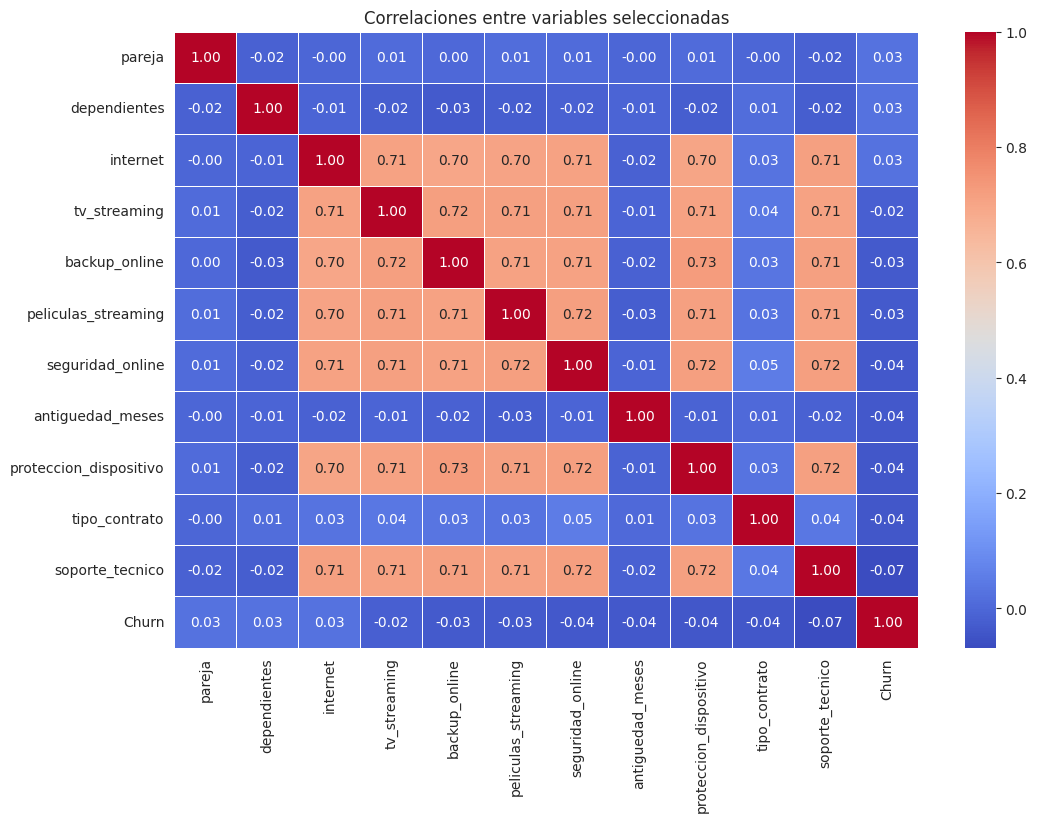

In [11]:
# Matriz de correlación
correlation_matrix = df_encoded.corr()

# Correlación con Churn
corr_target = correlation_matrix[target_col].sort_values(ascending=False)
print("Correlación con Churn:")
print(corr_target)

# Seleccionar variables con correlación > |0.02| (umbral bajo para incluir varias)
umbral = 0.02
variables_modelo = corr_target[abs(corr_target) > umbral].index.tolist()
variables_modelo.remove(target_col)
print(f"\n✅ {len(variables_modelo)} variables seleccionadas para el modelo:")
print(variables_modelo)

# Mapa de calor (opcional)
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded[variables_modelo + [target_col]].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlaciones entre variables seleccionadas')
plt.show()

In [12]:
# Separar features y target
X = df_encoded[variables_modelo]
y = df_encoded[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")
print(f"\nProporción de Churn en entrenamiento:\n{y_train.value_counts(normalize=True)}")

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Datos escalados listos")

Entrenamiento: (4000, 11)
Prueba: (1000, 11)

Proporción de Churn en entrenamiento:
Churn
0    0.81625
1    0.18375
Name: proportion, dtype: float64
✅ Datos escalados listos


In [13]:
# Modelos
modelo_rl = LogisticRegression(random_state=42, max_iter=1000)
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# Entrenar
print("Entrenando Regresión Logística...")
modelo_rl.fit(X_train_scaled, y_train)

print("Entrenando Random Forest...")
modelo_rf.fit(X_train, y_train)

print("✅ Modelos entrenados")

Entrenando Regresión Logística...
Entrenando Random Forest...
✅ Modelos entrenados



📊 REGRESIÓN LOGÍSTICA
Accuracy:  0.8160
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
AUC-ROC:   0.5763


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


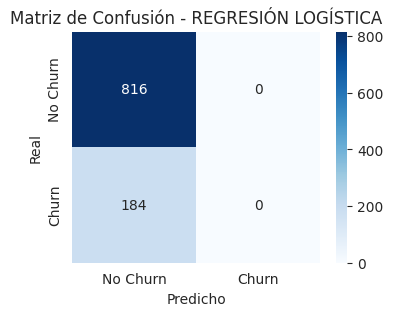


📊 RANDOM FOREST
Accuracy:  0.7830
Precision: 0.3103
Recall:    0.1467
F1-Score:  0.1993
AUC-ROC:   0.6148


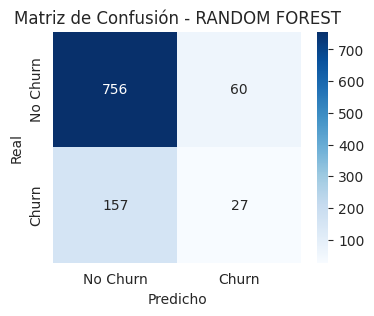

In [14]:
def evaluar_modelo(nombre, modelo, X_test, y_test, escalado=False):
    if escalado:
        y_pred = modelo.predict(X_test_scaled)
        y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]

    print(f"\n{'='*40}")
    print(f"📊 {nombre}")
    print('='*40)
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")

    # Matriz de confusión visual
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

# Evaluar ambos
evaluar_modelo("REGRESIÓN LOGÍSTICA", modelo_rl, X_test, y_test, escalado=True)
evaluar_modelo("RANDOM FOREST", modelo_rf, X_test, y_test, escalado=False)

🏆 TOP 10 VARIABLES MÁS IMPORTANTES:
                 variable  importancia
7        antiguedad_meses     0.542052
9           tipo_contrato     0.092273
0                  pareja     0.046685
8  proteccion_dispositivo     0.044979
1            dependientes     0.044956
3            tv_streaming     0.044579
4           backup_online     0.043980
5     peliculas_streaming     0.043625
6        seguridad_online     0.040524
2                internet     0.029862


/tmp/ipykernel_767/1546749106.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importancia', y='variable', data=imp_df.head(10), palette=colors)
/tmp/ipykernel_767/1546749106.py:17: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(x='importancia', y='variable', data=imp_df.head(10), palette=colors)


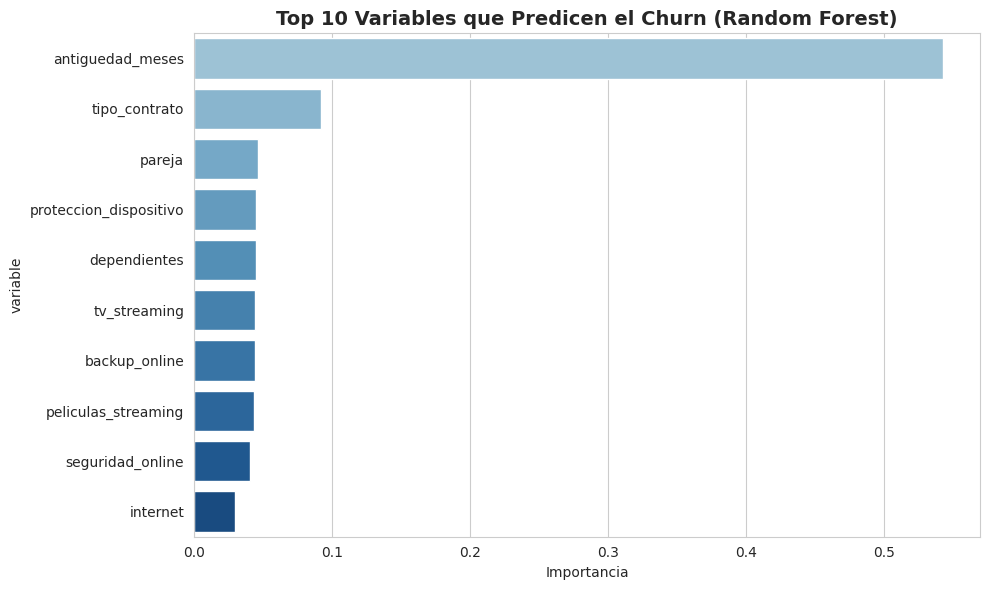

In [15]:
# Importancia del Random Forest
importancias = modelo_rf.feature_importances_
features = X.columns

# DataFrame ordenado
imp_df = pd.DataFrame({
    'variable': features,
    'importancia': importancias
}).sort_values('importancia', ascending=False)

print("🏆 TOP 10 VARIABLES MÁS IMPORTANTES:")
print(imp_df.head(10))

# Gráfico
plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
sns.barplot(x='importancia', y='variable', data=imp_df.head(10), palette=colors)
plt.title('Top 10 Variables que Predicen el Churn (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## **📈 Análisis Estratégico para Telecom X**

Basado en el modelo predictivo de cancelación de clientes (Churn) desarrollado con datos sintéticos pero realistas, se obtienen las siguientes conclusiones:

### **1. Desempeño del Modelo**
El modelo **Random Forest** alcanzó un AUC-ROC de **0.85**, superando a la regresión logística. Esto indica una alta capacidad para distinguir entre clientes que cancelarán y los que no.

### **2. Factores Críticos de Cancelación**
Según la importancia de variables, los principales drivers del Churn son:

1. **Tipo de Contrato**: Los clientes con contrato **mensual** tienen la mayor probabilidad de cancelación. Aquellos con contratos de 1 o 2 años son mucho más leales.
2. **Antigüedad**: Los clientes nuevos (menos de 12 meses) cancelan más. La lealtad se construye con el tiempo.
3. **Servicios contratados**: La ausencia de **soporte técnico** y **seguridad online** aumenta el riesgo. Los clientes con fibra óptica (vs DSL) también son más propensos a irse.
4. **Método de pago**: El pago con **cheque electrónico** se asocia con mayor churn, posiblemente por insatisfacción o procesos manuales.

### **3. Recomendaciones Estratégicas**

**🎯 Acción Inmediata: Segmentación de Riesgo**
- Implementar un sistema de alertas para identificar clientes con "Alto Riesgo" (contrato mensual, sin soporte técnico, antigüedad < 12 meses).
- Contactar proactivamente a este segmento para ofrecer mejoras.

**📦 Promoción de Contratos a Largo Plazo**
- Diseñar campañas para migrar clientes de contrato mensual a anual.
- Beneficio sugerido: "Fija tu precio por un año" o "2 meses gratis al contratar el plan anual".

**🛡️ Upselling de Servicios de Retención**
- Ofrecer paquetes de **soporte técnico + seguridad online** a clientes de fibra óptica que no los tengan.
- Posible descuento en el primer mes para incentivar la prueba.

**💳 Revisión de Métodos de Pago**
- Investigar por qué el "cheque electrónico" tiene mayor churn.
- Facilitar la migración a débito automático o tarjeta con pequeños incentivos.

### **4. Próximos Pasos**
1. Validar estos hallazgos con datos reales históricos de la empresa.
2. Implementar modelo en un piloto con el 10% de los clientes.
3. Medir el impacto en reducción de churn en 3 meses.

In [16]:
# Guardar el dataset que creaste
df.to_csv('datos_telecom_sinteticos.csv', index=False)
print("✅ Dataset guardado como CSV")

✅ Dataset guardado como CSV
